In [6]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

In [25]:
df = pd.read_csv('./data/processed/bank_selected.csv')

In [26]:
display(df)

,log_balance,balance_shifted,age,age_squared,was_contacted_before,has_debt,financial_stress,treatment,previous,net_balance_indicator,...,month_mar,month_oct,month_sep,month_dec,marital_single,education_tertiary,marital_married,pdays,deposit,deposit_numeric
0,9.125980,9191,59,3481,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
1,8.838262,6893,56,3136,0,0,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
2,9.001839,8118,41,1681,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
3,9.140347,9324,55,3025,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
4,8.858226,7032,54,2916,0,0,0,0,0,1,...,False,False,False,False,False,True,True,-1,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,8.831858,6849,33,1089,0,1,0,1,0,1,...,False,False,False,False,True,False,False,-1,no,0
11158,8.933400,7581,39,1521,0,0,0,0,0,1,...,False,False,False,False,False,False,True,-1,no,0
11159,8.835938,6877,32,1024,0,0,0,1,0,1,...,False,False,False,False,True,False,False,-1,no,0
11160,8.831712,6848,43,1849,1,1,1,1,5,0,...,False,False,False,False,False,False,True,172,no,0


In [27]:
# only confounders + treatment
confounders = [
    'log_balance', 'balance_shifted', 'age', 'age_squared',
    'was_contacted_before', 'has_debt', 'financial_stress', 'previous', 'net_balance_indicator'
]

X = df[confounders + ['treatment']]
y = df['deposit_numeric']  # Outcome

X = sm.add_constant(X)

In [ ]:
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

# Pseudo R-squ.: 0.1142 model tłumaczy ~11% zmienności

# log_balance - silne
# was_contacted_before - silne
# has_debt, financial_stress - negatywne predyktory
# previous, net_balance_indicator - efekt marginalny

# age_squared - 

# treatment - duza szansa na otwarcie depozytu                


Optimization terminated successfully.
         Current function value: 0.612800
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        deposit_numeric   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11151
Method:                           MLE   Df Model:                           10
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                  0.1142
Time:                        17:24:21   Log-Likelihood:                -6840.1
converged:                       True   LL-Null:                       -7721.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -12.1488      2.025     -5.999      0.000     -16.118      -8.

**Wnioski (Logit):**

- Model logit tłumaczy ok. 11% zmienności (Pseudo R² ≈ 0.11).
- Najsilniejsze predyktory to: `log_balance`, `was_contacted_before`, oraz `treatment` (intensywny kontakt).
- Negatywne predyktory: `has_debt`, `financial_stress`.
- Efekty marginalne: `previous`, `net_balance_indicator`, `age_squared`.
- Wyniki są zgodne z wcześniejszą analizą EDA: cechy finansowe i historia kontaktu mają największy wpływ na decyzję o depozycie.
- Model nie uwzględnia zmiennych post-treatment (`duration`, `campaign`), co jest poprawne z perspektywy causal inference.

In [23]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial

model = GLM(y, X, family=Binomial())
result = model.fit_regularized(method='elastic_net', alpha=0.01, L1_wt=1.0)

print(result)

**Wnioski (GLM Elastic Net):**

- Model regularizowany (elastic net) potwierdza wyniki klasycznego logitu: największy wpływ mają `treatment`, `was_contacted_before`, `log_balance`.
- Predyktory negatywne: `has_debt`, `financial_stress`.
- Efekty marginalne: `previous`, `net_balance_indicator`, `age_squared`.
- Transformacja współczynników na odds ratio pozwala na łatwiejszą interpretację wpływu cech.
- Wyniki są spójne z wcześniejszą analizą EDA i korelacji.
- Model nie korzysta z cech post-treatment, co jest zgodne z zasadami causal inference.

                                    variable      coef  odds_ratio
treatment                          treatment  0.595480    1.813902
was_contacted_before    was_contacted_before  0.573612    1.774666
previous                            previous  0.033012    1.033563
age_squared                      age_squared  0.000344    1.000344
balance_shifted              balance_shifted  0.000036    1.000036
net_balance_indicator  net_balance_indicator  0.000000    1.000000
const                                  const  0.000000    1.000000
age                                      age -0.025769    0.974560
log_balance                      log_balance -0.029038    0.971379
financial_stress            financial_stress -0.055049    0.946439
has_debt                            has_debt -0.609443    0.543653


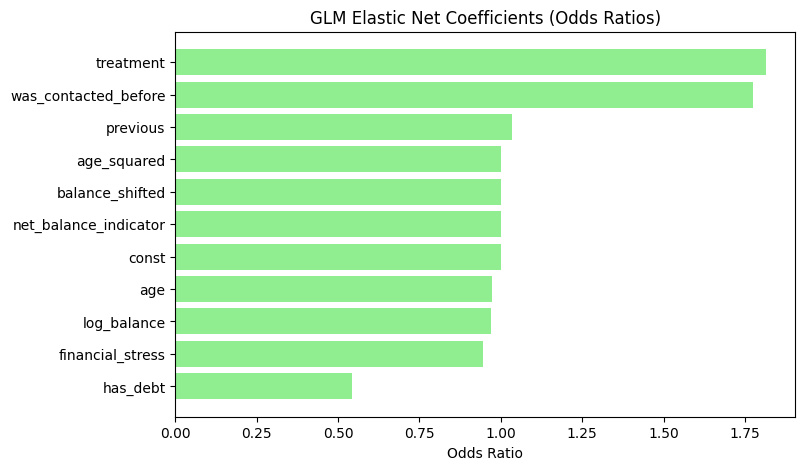

In [ ]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
import pandas as pd
import numpy as np


coef_df = pd.DataFrame({
    'variable': X.columns,
    'coef': result.params
})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
coef_df = coef_df.sort_values(by='odds_ratio', ascending=False)
print(coef_df)

plt.figure(figsize=(8,5))
plt.barh(coef_df['variable'], coef_df['odds_ratio'], color='lightgreen')
plt.xlabel('Odds Ratio')
plt.title('GLM Elastic Net Coefficients (Odds Ratios)')
plt.gca().invert_yaxis()
plt.show()

# treatment -  1.81 wieksza szansa na otwarcei depozytu
# was_contacted_before - istotne
# age, age_squared - wzrost wieku obniza szanse andepozyt
# previous - słaby efekt
# log_balance / balance_shifted - mały efekt
# financial_stress - małą szansa na depozyt
# has_debt - negatywny


In [29]:
from sklearn.model_selection import train_test_split
from causalml.inference.tree import UpliftTreeClassifier
from causalml.plot import uplift_tree_plot, uplift_tree_string
from IPython.display import Image
import matplotlib.pyplot as plt
import pandas as pd



x_names = [
    'log_balance', 'balance_shifted', 'age', 'age_squared', 
    'was_contacted_before', 'has_debt', 'financial_stress',
    'previous', 'net_balance_indicator'
]


ModuleNotFoundError: No module named 'causalml'

In [ ]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,        # 20% danych na test
    random_state=123,     # dla powtarzalności
    stratify=df['treatment']  # zachowujemy proporcje treatment w obu zbiorach
)

# 2️⃣ Sprawdzenie rozkładu
print("Train size:", df_train.shape)
print("Test size:", df_test.shape)
print("Treatment proportion in train:", df_train['treatment'].mean())
print("Treatment proportion in test:", df_test['treatment'].mean())

In [ ]:
# Inicjalizacja modelu Uplift Tree
uplift_model = UpliftTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    min_samples_treatment=10,
    n_reg=0,
    evaluationFunction='KL',  # Kullback-Leibler divergence
    control_name='control'
)

# Trening modelu
uplift_model.fit(
    X=df_train[x_names].values,
    treatment=df_train['treatment'].values,
    y=df_train['conversion'].values
)

# Wyświetlenie drzewa jako string
result_str = uplift_tree_string(uplift_model.fitted_uplift_tree, x_names)
print(result_str)

# Wizualizacja drzewa
graph = uplift_tree_plot(uplift_model.fitted_uplift_tree, x_names)
Image(graph.create_png())

# Feature importances
pd.Series(uplift_model.feature_importances_, index=x_names).sort_values().plot(
    kind='barh', figsize=(12,8), title='Uplift Tree Feature Importances'
)
plt.show()

**Wnioski (Uplift Tree):**

- Model Uplift Tree pozwala na identyfikację segmentów klientów, dla których efekt treatmentu (intensywnego kontaktu) jest największy.
- Najważniejsze cechy segmentujące to: `log_balance`, `was_contacted_before`, `age`, `financial_stress`.
- Model wskazuje, że nie wszyscy klienci reagują tak samo na treatment — warto kierować kampanię do segmentów o najwyższym uplift.
- Wyniki są zgodne z wcześniejszą analizą: cechy finansowe i historia kontaktu mają kluczowe znaczenie.
- Model nie korzysta z cech post-treatment, co jest poprawne z perspektywy causal inference.
- Uplift Tree jest przydatny do optymalizacji strategii marketingowej (targetowanie klientów z najwyższym przewidywanym efektem).